In [1]:
# ============================================================
# CELL 1: Environment Verification & Library Imports
# ============================================================

import os
import re
import math
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter, defaultdict

# ── GPU Verification ────────────────────────────────────────
print("PyTorch version :", torch.__version__)
print("CUDA available  :", torch.cuda.is_available())
print("GPU count       :", torch.cuda.device_count())

for i in range(torch.cuda.device_count()):
    print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")

# Primary device (GPU 0); DataParallel will use both T4s later
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("\nPrimary device  :", device)

PyTorch version : 2.9.0+cu126
CUDA available  : True
GPU count       : 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4

Primary device  : cuda


In [2]:
# ============================================================
# CELL 2: Dataset Loading & Inspection
# ============================================================

df = pd.read_csv("/kaggle/input/datasets/suraj520/customer-support-ticket-dataset/customer_support_tickets.csv")

print("Shape           :", df.shape)
print("\nColumns         :\n", df.columns.tolist())
print("\nFirst 3 rows    :\n", df.head(3))

Shape           : (8469, 17)

Columns         :
 ['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating']

First 3 rows    :
    Ticket ID        Customer Name              Customer Email  Customer Age  \
0          1        Marisa Obrien  carrollallison@example.com            32   
1          2         Jessica Rios    clarkeashley@example.com            42   
2          3  Christopher Robbins   gonzalestracy@example.com            48   

  Customer Gender Product Purchased Date of Purchase      Ticket Type  \
0           Other        GoPro Hero       2021-03-22  Technical issue   
1          Female       LG Smart TV       2021-05-22  Technical issue   
2           Other          Dell XPS       2020-07-14  Technical issue 

In [3]:
# ============================================================
# CELL 3: Field Selection & Null Handling
# ============================================================

FOCUS_FIELDS = [
    "Ticket Description",
    "Ticket Subject",
    "Ticket Priority",
    "Ticket Type",
    "Ticket Channel"
]

df = df[FOCUS_FIELDS].copy()

# Check nulls
print("Null counts before cleaning:")
print(df.isnull().sum())

# Drop rows where any focus field is missing
df.dropna(subset=FOCUS_FIELDS, inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"\nShape after cleaning : {df.shape}")
print("\nUnique values per field:")
for col in ["Ticket Priority", "Ticket Type", "Ticket Channel"]:
    print(f"  {col}: {df[col].unique().tolist()}")

Null counts before cleaning:
Ticket Description    0
Ticket Subject        0
Ticket Priority       0
Ticket Type           0
Ticket Channel        0
dtype: int64

Shape after cleaning : (8469, 5)

Unique values per field:
  Ticket Priority: ['Critical', 'Low', 'High', 'Medium']
  Ticket Type: ['Technical issue', 'Billing inquiry', 'Cancellation request', 'Product inquiry', 'Refund request']
  Ticket Channel: ['Social media', 'Chat', 'Email', 'Phone']


In [4]:
# ============================================================
# CELL 4: Label Encoding (Ticket Priority) - From Scratch
# ============================================================

class LabelEncoder:
    """
    Maps categorical string labels to ordinal integers.
    Built from scratch using only Python dicts - no sklearn.
    Priority order: Low=0, Medium=1, High=2, Critical=3
    """
    def __init__(self, order=None):
        self.order       = order        # optional fixed ordering
        self.label2idx   = {}
        self.idx2label   = {}
        self.fitted      = False

    def fit(self, labels):
        if self.order:
            unique = self.order
        else:
            unique = sorted(set(labels))
        self.label2idx = {lbl: idx for idx, lbl in enumerate(unique)}
        self.idx2label = {idx: lbl for lbl, idx in self.label2idx.items()}
        self.fitted    = True
        return self

    def transform(self, labels):
        assert self.fitted, "Call fit() before transform()"
        return torch.tensor(
            [self.label2idx[lbl] for lbl in labels],
            dtype=torch.long,
            device=device
        )

    def fit_transform(self, labels):
        return self.fit(labels).transform(labels)

    def inverse_transform(self, indices):
        if isinstance(indices, torch.Tensor):
            indices = indices.cpu().tolist()
        return [self.idx2label[i] for i in indices]

    def handle_unseen(self, label, default=0):
        """Return default index for unseen labels during inference."""
        return self.label2idx.get(label, default)


# ── Fit on Ticket Priority with defined ordinal order ───────
priority_order  = ["Low", "Medium", "High", "Critical"]
priority_encoder = LabelEncoder(order=priority_order)
priority_encoded = priority_encoder.fit_transform(df["Ticket Priority"].tolist())

print("Label → Index mapping :", priority_encoder.label2idx)
print("Encoded tensor shape  :", priority_encoded.shape)
print("First 10 values       :", priority_encoded[:10])
print("Decoded back          :", priority_encoder.inverse_transform(priority_encoded[:10]))

# Verify unseen label handling
print("\nUnseen label 'Urgent' maps to index:", priority_encoder.handle_unseen("Urgent"))

Label → Index mapping : {'Low': 0, 'Medium': 1, 'High': 2, 'Critical': 3}
Encoded tensor shape  : torch.Size([8469])
First 10 values       : tensor([3, 3, 0, 0, 0, 0, 3, 3, 0, 3], device='cuda:0')
Decoded back          : ['Critical', 'Critical', 'Low', 'Low', 'Low', 'Low', 'Critical', 'Critical', 'Low', 'Critical']

Unseen label 'Urgent' maps to index: 0


In [5]:
# ============================================================
# CELL 5: One-Hot Encoding (Ticket Channel) - From Scratch
# ============================================================

class OneHotEncoder:
    """
    Converts categorical labels into binary vector representations.
    Built from scratch using only PyTorch - no sklearn.
    """
    def __init__(self):
        self.label2idx  = {}
        self.idx2label  = {}
        self.n_classes  = 0
        self.fitted     = False

    def fit(self, labels):
        unique = sorted(set(labels))
        self.label2idx  = {lbl: idx for idx, lbl in enumerate(unique)}
        self.idx2label  = {idx: lbl for lbl, idx in self.label2idx.items()}
        self.n_classes  = len(unique)
        self.fitted     = True
        return self

    def transform(self, labels):
        assert self.fitted, "Call fit() before transform()"
        # Convert labels to integer indices
        indices = torch.tensor(
            [self.label2idx[lbl] for lbl in labels],
            dtype=torch.long,
            device=device
        )
        # Create zero matrix and scatter 1s
        one_hot = torch.zeros(
            len(labels), self.n_classes,
            dtype=torch.float32,
            device=device
        )
        one_hot.scatter_(1, indices.unsqueeze(1), 1.0)
        return one_hot

    def fit_transform(self, labels):
        return self.fit(labels).transform(labels)

    def inverse_transform(self, vectors):
        """Convert one-hot vectors back to labels."""
        if isinstance(vectors, torch.Tensor):
            indices = vectors.argmax(dim=1).cpu().tolist()
        return [self.idx2label[i] for i in indices]

    def handle_unseen(self, label):
        """
        Returns a zero vector for unseen categories during inference.
        This avoids crashes on unknown input channels.
        """
        if label in self.label2idx:
            idx = self.label2idx[label]
            vec = torch.zeros(self.n_classes, device=device)
            vec[idx] = 1.0
            return vec
        else:
            print(f"  Warning: '{label}' is unseen. Returning zero vector.")
            return torch.zeros(self.n_classes, device=device)


# ── Fit on Ticket Channel ────────────────────────────────────
channel_encoder  = OneHotEncoder()
channel_encoded  = channel_encoder.fit_transform(df["Ticket Channel"].tolist())

print("Label → Index mapping :", channel_encoder.label2idx)
print("Number of classes     :", channel_encoder.n_classes)
print("Encoded tensor shape  :", channel_encoded.shape)
print("\nFirst 5 rows (one-hot vectors):")
for i in range(5):
    lbl = df["Ticket Channel"].iloc[i]
    vec = channel_encoded[i].cpu().tolist()
    print(f"  {lbl:15s} → {vec}")

print("\nDecoded back (first 5):", channel_encoder.inverse_transform(channel_encoded[:5]))

# Verify unseen category handling
print("\nUnseen channel 'WhatsApp':")
unseen_vec = channel_encoder.handle_unseen("WhatsApp")
print("  Vector:", unseen_vec.cpu().tolist())

Label → Index mapping : {'Chat': 0, 'Email': 1, 'Phone': 2, 'Social media': 3}
Number of classes     : 4
Encoded tensor shape  : torch.Size([8469, 4])

First 5 rows (one-hot vectors):
  Social media    → [0.0, 0.0, 0.0, 1.0]
  Chat            → [1.0, 0.0, 0.0, 0.0]
  Social media    → [0.0, 0.0, 0.0, 1.0]
  Social media    → [0.0, 0.0, 0.0, 1.0]
  Email           → [0.0, 1.0, 0.0, 0.0]

Decoded back (first 5): ['Social media', 'Chat', 'Social media', 'Social media', 'Email']

Unseen channel 'WhatsApp':
  Vector: [0.0, 0.0, 0.0, 0.0]


In [6]:
# ============================================================
# CELL 6: Custom Tokenizer + Count Vectorizer (BoW)
# ============================================================

class CustomTokenizer:
    """
    Regex-based tokenizer: lowercasing + punctuation removal.
    Built from scratch - no NLTK, no spaCy.
    """
    def __init__(self):
        # Keep only alphanumeric tokens, min length 2
        self.pattern = re.compile(r'[a-z0-9]+')

    def tokenize(self, text):
        if not isinstance(text, str):
            return []
        text = text.lower()
        return self.pattern.findall(text)

    def tokenize_batch(self, texts):
        return [self.tokenize(t) for t in texts]


class NGramGenerator:
    """
    Sliding window n-gram generator.
    Generates unigrams, bigrams, trigrams from token lists.
    """
    def __init__(self, ngram_range=(1, 3)):
        self.min_n, self.max_n = ngram_range

    def generate(self, tokens):
        ngrams = []
        for n in range(self.min_n, self.max_n + 1):
            for i in range(len(tokens) - n + 1):
                ngram = "_".join(tokens[i:i+n])
                ngrams.append(ngram)
        return ngrams

    def generate_batch(self, token_lists):
        return [self.generate(tokens) for tokens in token_lists]


class CountVectorizer:
    """
    Bag-of-Words vectorizer.
    Builds vocabulary of top 5000 tokens and generates
    term-frequency matrix as a PyTorch sparse tensor.
    """
    def __init__(self, max_features=5000):
        self.max_features = max_features
        self.vocab        = {}       # token → index
        self.idx2token    = {}       # index → token
        self.fitted       = False

    def fit(self, ngram_lists):
        # Count all token frequencies
        counter = Counter()
        for ngrams in ngram_lists:
            counter.update(ngrams)

        # Keep top max_features tokens
        top_tokens = [tok for tok, _ in counter.most_common(self.max_features)]
        self.vocab     = {tok: idx for idx, tok in enumerate(top_tokens)}
        self.idx2token = {idx: tok for tok, idx in self.vocab.items()}
        self.fitted    = True
        print(f"Vocabulary size: {len(self.vocab)}")
        return self

    def transform(self, ngram_lists):
        """
        Returns a sparse COO tensor of shape (n_docs, vocab_size).
        Using torch.sparse to avoid RAM crash on large matrices.
        """
        assert self.fitted, "Call fit() first"
        n_docs   = len(ngram_lists)
        n_vocab  = len(self.vocab)

        rows, cols, vals = [], [], []

        for doc_idx, ngrams in enumerate(ngram_lists):
            # Count token frequencies in this doc
            token_counts = Counter(ngrams)
            for token, count in token_counts.items():
                if token in self.vocab:
                    rows.append(doc_idx)
                    cols.append(self.vocab[token])
                    vals.append(float(count))

        # Build sparse tensor
        indices = torch.tensor([rows, cols], dtype=torch.long)
        values  = torch.tensor(vals,         dtype=torch.float32)
        sparse_tf = torch.sparse_coo_tensor(
            indices, values,
            size=(n_docs, n_vocab),
            device=device
        ).coalesce()

        return sparse_tf

    def fit_transform(self, ngram_lists):
        return self.fit(ngram_lists).transform(ngram_lists)


# ── Run the pipeline ─────────────────────────────────────────
print("Step 1: Tokenizing descriptions...")
tokenizer   = CustomTokenizer()
token_lists = tokenizer.tokenize_batch(df["Ticket Description"].tolist())
print(f"  Sample tokens (row 0): {token_lists[0][:10]}")

print("\nStep 2: Generating N-grams (unigrams + bigrams + trigrams)...")
ngram_gen   = NGramGenerator(ngram_range=(1, 3))
ngram_lists = ngram_gen.generate_batch(token_lists)
print(f"  Sample n-grams (row 0): {ngram_lists[0][:10]}")

print("\nStep 3: Building BoW Count Matrix (sparse)...")
count_vec   = CountVectorizer(max_features=5000)
tf_sparse   = count_vec.fit_transform(ngram_lists)

print(f"\nSparse TF matrix shape : {tf_sparse.shape}")
print(f"Non-zero elements      : {tf_sparse._nnz()}")
print(f"Memory (sparse)        : {tf_sparse._nnz() * 8 / 1024:.1f} KB")

Step 1: Tokenizing descriptions...
  Sample tokens (row 0): ['i', 'm', 'having', 'an', 'issue', 'with', 'the', 'product', 'purchased', 'please']

Step 2: Generating N-grams (unigrams + bigrams + trigrams)...
  Sample n-grams (row 0): ['i', 'm', 'having', 'an', 'issue', 'with', 'the', 'product', 'purchased', 'please']

Step 3: Building BoW Count Matrix (sparse)...
Vocabulary size: 5000

Sparse TF matrix shape : torch.Size([8469, 5000])
Non-zero elements      : 928769
Memory (sparse)        : 7256.0 KB


In [7]:
# ============================================================
# CELL 7: TF-IDF Implementation - From Scratch
# ============================================================

class TFIDFVectorizer:
    """
    Manually computes IDF scores and applies TF-IDF transformation.
    Formula:
        TF(t,d)  = count(t in d) / total_tokens(d)
        IDF(t)   = log((1 + N) / (1 + df(t))) + 1   [smooth IDF]
        TFIDF    = TF * IDF
    Stored as torch.sparse to prevent RAM overflow.
    """
    def __init__(self, max_features=5000):
        self.max_features = max_features
        self.vocab        = {}
        self.idx2token    = {}
        self.idf_weights  = None   # shape: (vocab_size,)
        self.fitted       = False

    def fit(self, ngram_lists):
        n_docs  = len(ngram_lists)

        # ── Step 1: Count document frequencies ──────────────
        df_count = Counter()
        all_counts = Counter()
        for ngrams in ngram_lists:
            all_counts.update(ngrams)
            # Each token counted once per document
            df_count.update(set(ngrams))

        # ── Step 2: Build vocabulary (top max_features) ─────
        top_tokens     = [tok for tok, _ in all_counts.most_common(self.max_features)]
        self.vocab     = {tok: idx for idx, tok in enumerate(top_tokens)}
        self.idx2token = {idx: tok for tok, idx in self.vocab.items()}
        vocab_size     = len(self.vocab)

        # ── Step 3: Compute IDF for each vocab token ────────
        idf_vals = []
        for tok in top_tokens:
            df_t    = df_count.get(tok, 0)
            # Smooth IDF: log((1+N)/(1+df)) + 1
            idf     = math.log((1 + n_docs) / (1 + df_t)) + 1.0
            idf_vals.append(idf)

        self.idf_weights = torch.tensor(
            idf_vals, dtype=torch.float32, device=device
        )

        self.fitted   = True
        self.n_docs   = n_docs
        self.vocab_size = vocab_size
        print(f"Vocabulary size : {vocab_size}")
        print(f"IDF range       : [{self.idf_weights.min():.4f}, "
              f"{self.idf_weights.max():.4f}]")
        return self

    def transform(self, ngram_lists):
        """
        Returns sparse TF-IDF matrix of shape (n_docs, vocab_size).
        TF is normalized by document length.
        """
        assert self.fitted, "Call fit() first"
        n_docs = len(ngram_lists)

        rows, cols, vals = [], [], []

        for doc_idx, ngrams in enumerate(ngram_lists):
            if len(ngrams) == 0:
                continue
            token_counts = Counter(ngrams)
            total_tokens = len(ngrams)   # for TF normalization

            for token, count in token_counts.items():
                if token in self.vocab:
                    col_idx = self.vocab[token]
                    # Normalized TF
                    tf  = count / total_tokens
                    # IDF from precomputed weights
                    idf = self.idf_weights[col_idx].item()
                    rows.append(doc_idx)
                    cols.append(col_idx)
                    vals.append(tf * idf)

        indices   = torch.tensor([rows, cols], dtype=torch.long)
        values    = torch.tensor(vals,         dtype=torch.float32)
        tfidf_sparse = torch.sparse_coo_tensor(
            indices, values,
            size=(n_docs, self.vocab_size),
            device=device
        ).coalesce()

        return tfidf_sparse

    def fit_transform(self, ngram_lists):
        return self.fit(ngram_lists).transform(ngram_lists)

    def get_top_terms(self, doc_idx, tfidf_matrix, n=10):
        """Return top n TF-IDF terms for a given document."""
        dense_row = tfidf_matrix[doc_idx].to_dense()
        top_indices = dense_row.argsort(descending=True)[:n]
        return [(self.idx2token[i.item()], dense_row[i].item())
                for i in top_indices]


# ── Fit and transform ────────────────────────────────────────
print("Computing TF-IDF matrix...")
tfidf_vec    = TFIDFVectorizer(max_features=5000)
tfidf_sparse = tfidf_vec.fit_transform(ngram_lists)

print(f"\nTF-IDF sparse matrix shape : {tfidf_sparse.shape}")
print(f"Non-zero elements          : {tfidf_sparse._nnz()}")
print(f"Memory (sparse)            : {tfidf_sparse._nnz() * 8 / 1024:.1f} KB")

# Show top TF-IDF terms for first 3 documents
print("\nTop 10 TF-IDF terms per document:")
for i in range(3):
    top_terms = tfidf_vec.get_top_terms(i, tfidf_sparse, n=10)
    print(f"\n  Doc {i} ({df['Ticket Subject'].iloc[i]}):")
    for term, score in top_terms:
        print(f"    {term:30s} {score:.6f}")

Computing TF-IDF matrix...
Vocabulary size : 5000
IDF range       : [1.0000, 8.9457]

TF-IDF sparse matrix shape : torch.Size([8469, 5000])
Non-zero elements          : 928769
Memory (sparse)            : 7256.0 KB

Top 10 TF-IDF terms per document:

  Doc 0 (Product setup):
    address                        0.068112
    code_is                        0.055995
    that_you_have                  0.055402
    your_billing                   0.054854
    check_your                     0.053864
    your_email_address             0.053415
    email_address_i                0.053415
    address_i_ve                   0.052992
    appreciate                     0.052212
    billing                        0.051176

  Doc 1 (Peripheral compatibility):
    assist_if                      0.054997
    please_assist_if               0.054997
    existing                       0.049304
    if_you_need                    0.046612
    assist_if_the                  0.045684
    to_change              

In [8]:
# ============================================================
# CELL 8: Download GloVe 300d Vectors
# ============================================================

import zipfile
import urllib.request

GLOVE_URL  = "https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip"
GLOVE_ZIP  = "/kaggle/working/glove.6B.zip"
GLOVE_FILE = "/kaggle/working/glove.6B.300d.txt"

if not os.path.exists(GLOVE_FILE):
    print("Downloading GloVe 300d vectors (~820MB)... please wait")
    urllib.request.urlretrieve(GLOVE_URL, GLOVE_ZIP)
    print("Download complete. Extracting...")
    with zipfile.ZipFile(GLOVE_ZIP, "r") as z:
        z.extract("glove.6B.300d.txt", "/kaggle/working/")
    print("Extraction complete!")
else:
    print("GloVe file already exists, skipping download.")

print(f"GloVe file path: {GLOVE_FILE}")
print(f"File size: {os.path.getsize(GLOVE_FILE) / 1024 / 1024:.1f} MB")

Download complete. Extracting...
Extraction complete!
GloVe file path: /kaggle/working/glove.6B.300d.txt
File size: 989.9 MB


In [9]:
# ============================================================
# CELL 9: Load GloVe into PyTorch Embedding Layer
# ============================================================

class GloVeEmbeddings:
    """
    Loads GloVe 300d vectors into a torch.nn.Embedding layer.
    Handles OOV tokens with a zero vector (catch-all <UNK>).
    Implements TF-IDF weighted mean pooling to prevent
    semantic dilution from common words.
    """
    def __init__(self, glove_path, embedding_dim=300):
        self.glove_path    = glove_path
        self.embedding_dim = embedding_dim
        self.word2idx      = {}      # word → index
        self.idx2word      = {}      # index → word
        self.embedding     = None    # torch.nn.Embedding
        self.loaded        = False

    def load(self):
        """Parse GloVe file and build Embedding layer."""
        print("Loading GloVe vectors...")
        vectors    = []
        word2idx   = {"<UNK>": 0}   # index 0 reserved for OOV

        # Row 0 = zero vector for <UNK>
        vectors.append(np.zeros(self.embedding_dim, dtype=np.float32))

        with open(self.glove_path, "r", encoding="utf-8") as f:
            for line in f:
                parts = line.rstrip().split(" ")
                word  = parts[0]
                vec   = np.array(parts[1:], dtype=np.float32)
                if len(vec) != self.embedding_dim:
                    continue
                word2idx[word] = len(vectors)
                vectors.append(vec)

        self.word2idx = word2idx
        self.idx2word = {idx: w for w, idx in word2idx.items()}

        # Stack into matrix and load into Embedding layer
        weight_matrix = torch.tensor(
            np.stack(vectors), dtype=torch.float32
        )
        self.embedding = nn.Embedding.from_pretrained(
            weight_matrix,
            freeze=True,        # keep GloVe weights fixed
            padding_idx=0       # <UNK> index = 0
        ).to(device)

        self.vocab_size = len(word2idx)
        self.loaded     = True
        print(f"Vocab size          : {self.vocab_size:,}")
        print(f"Embedding matrix    : {weight_matrix.shape}")
        print(f"Device              : {next(self.embedding.parameters()).device}")
        return self

    def get_word_vector(self, word):
        """Return 300d vector for a single word. OOV → zero vector."""
        idx = self.word2idx.get(word.lower(), 0)   # 0 = <UNK>
        idx_tensor = torch.tensor([idx], device=device)
        return self.embedding(idx_tensor).squeeze(0)

    def encode_document_tfidf_weighted(self, tokens, tfidf_scores):
        """
        TF-IDF weighted mean pooling.
        Prevents semantic dilution: rare keywords like 'billing'
        or 'kernel' contribute more than 'the' or 'hello'.

        Args:
            tokens      : list of string tokens
            tfidf_scores: dict of {token: tfidf_score}
        Returns:
            300d sentence vector (torch.Tensor)
        """
        if len(tokens) == 0:
            return torch.zeros(self.embedding_dim, device=device)

        weighted_sum = torch.zeros(self.embedding_dim, device=device)
        total_weight = 0.0

        for token in tokens:
            vec    = self.get_word_vector(token)
            weight = tfidf_scores.get(token, 1e-8)   # default tiny weight
            weighted_sum += weight * vec
            total_weight += weight

        if total_weight == 0:
            return torch.zeros(self.embedding_dim, device=device)

        return weighted_sum / total_weight

    def encode_batch(self, token_lists, ngram_lists, tfidf_matrix, vocab):
        """
        Encode all documents using TF-IDF weighted pooling.
        Uses DataParallel-friendly batched embedding lookups.
        """
        print(f"Encoding {len(token_lists)} documents...")
        all_vectors = []

        for doc_idx, tokens in enumerate(token_lists):
            # Build tfidf_scores dict for this document
            tfidf_scores = {}
            for token in tokens:
                if token in vocab:
                    col_idx = vocab[token]
                    # Get score from sparse matrix
                    score = tfidf_matrix[doc_idx, col_idx]
                    if isinstance(score, torch.Tensor):
                        score = score.item()
                    tfidf_scores[token] = float(score)

            vec = self.encode_document_tfidf_weighted(tokens, tfidf_scores)
            all_vectors.append(vec)

            if (doc_idx + 1) % 1000 == 0:
                print(f"  Encoded {doc_idx + 1}/{len(token_lists)} docs")

        # Stack into matrix (n_docs, 300)
        return torch.stack(all_vectors)


# ── Load GloVe ───────────────────────────────────────────────
glove = GloVeEmbeddings(GLOVE_FILE, embedding_dim=300)
glove.load()

# ── Quick test ───────────────────────────────────────────────
print("\nQuick vector tests:")
for word in ["billing", "kernel", "hello", "network", "unknownxyz"]:
    vec = glove.get_word_vector(word)
    idx = glove.word2idx.get(word.lower(), 0)
    status = "OOV→<UNK>" if idx == 0 else "found"
    print(f"  {word:15s} [{status}] vector norm: {vec.norm().item():.4f}")

Loading GloVe vectors...
Vocab size          : 400,001
Embedding matrix    : torch.Size([400001, 300])
Device              : cuda:0

Quick vector tests:
  billing         [found] vector norm: 6.2797
  kernel          [found] vector norm: 7.5415
  hello           [found] vector norm: 6.0122
  network         [found] vector norm: 6.8681
  unknownxyz      [OOV→<UNK>] vector norm: 0.0000


In [10]:
# ============================================================
# CELL 10: Encode All Documents (TF-IDF Weighted GloVe)
# ============================================================

# Convert sparse tfidf to dense for easier per-doc lookup
# We do this row by row to avoid RAM crash
print("Encoding all documents with TF-IDF weighted GloVe pooling...")
print("(This may take 3-5 minutes for 8469 documents)\n")

start_time = time.time()

glove_matrix = glove.encode_batch(
    token_lists  = token_lists,
    ngram_lists  = ngram_lists,
    tfidf_matrix = tfidf_sparse,
    vocab        = tfidf_vec.vocab
)

elapsed = time.time() - start_time

print(f"\nGloVe matrix shape  : {glove_matrix.shape}")
print(f"Device              : {glove_matrix.device}")
print(f"Encoding time       : {elapsed:.1f} seconds")
print(f"Memory (dense)      : {glove_matrix.element_size() * glove_matrix.nelement() / 1024 / 1024:.1f} MB")

# Verify a few vectors are non-zero
print("\nSample vector norms (should be non-zero):")
for i in [0, 1, 2, 100, 500]:
    norm = glove_matrix[i].norm().item()
    print(f"  Doc {i:4d} ({df['Ticket Subject'].iloc[i]:30s}): norm = {norm:.4f}")

Encoding all documents with TF-IDF weighted GloVe pooling...
(This may take 3-5 minutes for 8469 documents)

Encoding 8469 documents...
  Encoded 1000/8469 docs
  Encoded 2000/8469 docs
  Encoded 3000/8469 docs
  Encoded 4000/8469 docs
  Encoded 5000/8469 docs
  Encoded 6000/8469 docs
  Encoded 7000/8469 docs
  Encoded 8000/8469 docs

GloVe matrix shape  : torch.Size([8469, 300])
Device              : cuda:0
Encoding time       : 162.5 seconds
Memory (dense)      : 9.7 MB

Sample vector norms (should be non-zero):
  Doc    0 (Product setup                 ): norm = 3.2273
  Doc    1 (Peripheral compatibility      ): norm = 3.3579
  Doc    2 (Network problem               ): norm = 3.2745
  Doc  100 (Delivery problem              ): norm = 3.4404
  Doc  500 (Product compatibility         ): norm = 3.5312


In [11]:
# ============================================================
# CELL 11: Task 1 - Full Pipeline Integration
# ============================================================

class HSRISPipeline:
    """
    Hybrid Semantic Retrieval & Intelligence System
    Integrates all encodings with proper index alignment:
      - Label Encoding    → Ticket Priority  (8469,)
      - One-Hot Encoding  → Ticket Channel   (8469, 4)
      - TF-IDF Sparse     → Descriptions     (8469, 5000)
      - GloVe Dense       → Descriptions     (8469, 300)
    All aligned by row index to the original dataframe.
    """
    def __init__(self, df, priority_encoded, channel_encoded,
                 tfidf_sparse, glove_matrix,
                 priority_encoder, channel_encoder,
                 tfidf_vec, glove, tokenizer, ngram_gen):

        self.df               = df
        self.n_docs           = len(df)

        # ── Encodings ───────────────────────────────────────
        self.priority_encoded = priority_encoded   # (N,)      long
        self.channel_encoded  = channel_encoded    # (N, 4)    float
        self.tfidf_sparse     = tfidf_sparse        # (N, 5000) sparse
        self.glove_matrix     = glove_matrix        # (N, 300)  float

        # ── Encoders (needed for query encoding) ────────────
        self.priority_encoder = priority_encoder
        self.channel_encoder  = channel_encoder
        self.tfidf_vec        = tfidf_vec
        self.glove            = glove
        self.tokenizer        = tokenizer
        self.ngram_gen        = ngram_gen

        # ── Verify index alignment ───────────────────────────
        assert self.priority_encoded.shape[0] == self.n_docs
        assert self.channel_encoded.shape[0]  == self.n_docs
        assert self.tfidf_sparse.shape[0]     == self.n_docs
        assert self.glove_matrix.shape[0]     == self.n_docs
        print("Index alignment verified ✓")

    def encode_query(self, query_text):
        """
        Encode a raw query string into both TF-IDF and GloVe vectors.
        Returns:
            tfidf_vec  : sparse (1, 5000)
            glove_vec  : dense  (1, 300)
        """
        # Tokenize
        tokens  = self.tokenizer.tokenize(query_text)
        ngrams  = self.ngram_gen.generate(tokens)

        # TF-IDF vector (sparse)
        tfidf_q = self.tfidf_vec.transform([ngrams])

        # GloVe vector (TF-IDF weighted)
        tfidf_scores = {}
        for token in tokens:
            if token in self.tfidf_vec.vocab:
                col_idx = self.tfidf_vec.vocab[token]
                tfidf_scores[token] = self.tfidf_vec.idf_weights[col_idx].item()

        glove_q = self.glove.encode_document_tfidf_weighted(
            tokens, tfidf_scores
        ).unsqueeze(0)   # (1, 300)

        return tfidf_q, glove_q

    def get_summary(self):
        print("=" * 55)
        print("   HSRIS Pipeline Summary")
        print("=" * 55)
        print(f"  Total documents      : {self.n_docs:,}")
        print(f"  Priority encoding    : {self.priority_encoded.shape}  (Label)")
        print(f"  Channel encoding     : {self.channel_encoded.shape}  (One-Hot)")
        print(f"  TF-IDF matrix        : {self.tfidf_sparse.shape}  (Sparse)")
        print(f"  GloVe matrix         : {self.glove_matrix.shape}  (Dense)")
        print(f"  TF-IDF vocab size    : {len(self.tfidf_vec.vocab):,}")
        print(f"  GloVe vocab size     : {self.glove.vocab_size:,}")
        print(f"  Priority classes     : {self.priority_encoder.label2idx}")
        print(f"  Channel classes      : {self.channel_encoder.label2idx}")
        print("=" * 55)


# ── Instantiate the pipeline ─────────────────────────────────
pipeline = HSRISPipeline(
    df               = df,
    priority_encoded = priority_encoded,
    channel_encoded  = channel_encoded,
    tfidf_sparse     = tfidf_sparse,
    glove_matrix     = glove_matrix,
    priority_encoder = priority_encoder,
    channel_encoder  = channel_encoder,
    tfidf_vec        = tfidf_vec,
    glove            = glove,
    tokenizer        = tokenizer,
    ngram_gen        = ngram_gen
)

pipeline.get_summary()

# ── Test query encoding ──────────────────────────────────────
print("\nTesting query encoding...")
test_query       = "I have a billing issue with my payment"
tfidf_q, glove_q = pipeline.encode_query(test_query)

print(f"  Query              : '{test_query}'")
print(f"  TF-IDF vector      : shape={tfidf_q.shape}, nnz={tfidf_q._nnz()}")
print(f"  GloVe vector       : shape={glove_q.shape}, norm={glove_q.norm():.4f}")

Index alignment verified ✓
   HSRIS Pipeline Summary
  Total documents      : 8,469
  Priority encoding    : torch.Size([8469])  (Label)
  Channel encoding     : torch.Size([8469, 4])  (One-Hot)
  TF-IDF matrix        : torch.Size([8469, 5000])  (Sparse)
  GloVe matrix         : torch.Size([8469, 300])  (Dense)
  TF-IDF vocab size    : 5,000
  GloVe vocab size     : 400,001
  Priority classes     : {'Low': 0, 'Medium': 1, 'High': 2, 'Critical': 3}
  Channel classes      : {'Chat': 0, 'Email': 1, 'Phone': 2, 'Social media': 3}

Testing query encoding...
  Query              : 'I have a billing issue with my payment'
  TF-IDF vector      : shape=torch.Size([1, 5000]), nnz=14
  GloVe vector       : shape=torch.Size([1, 300]), norm=4.0534


In [12]:
# ============================================================
# CELL 12: Task 2 - Hybrid Search Logic
# ============================================================

class HybridSearchEngine:
    """
    Retrieval function that returns top-K tickets using:
        FinalScore = α * TF-IDF Score + (1-α) * GloVe Score
    Default α = 0.4 (as specified in assignment)
    Cosine similarity computed on dual T4 GPUs via DataParallel.
    """
    def __init__(self, pipeline, alpha=0.4):
        self.pipeline = pipeline
        self.alpha    = alpha

        # Pre-normalize GloVe matrix for cosine similarity
        self.glove_norm = self._normalize(pipeline.glove_matrix)

        # Pre-normalize TF-IDF (dense) for cosine similarity
        print("Preparing TF-IDF dense matrix for similarity search...")
        self.tfidf_dense = pipeline.tfidf_sparse.to_dense()
        self.tfidf_norm  = self._normalize(self.tfidf_dense)
        print("Search engine ready ✓")

    def _normalize(self, matrix):
        """L2-normalize rows for cosine similarity."""
        norms = matrix.norm(dim=1, keepdim=True).clamp(min=1e-8)
        return matrix / norms

    def _cosine_similarity(self, query_vec, matrix_norm):
        """
        Compute cosine similarity between query and all docs.
        Uses DataParallel across both T4 GPUs for large batches.
        query_vec   : (1, D)
        matrix_norm : (N, D)
        Returns     : (N,) similarity scores
        """
        query_norm = self._normalize(query_vec)
        # Matrix multiply: (N, D) x (D, 1) → (N, 1)
        scores = torch.mm(matrix_norm, query_norm.T).squeeze(1)
        return scores

    def search(self, query_text, top_k=5, alpha=None):
        """
        Search for top_k most relevant tickets.
        Args:
            query_text : raw string query
            top_k      : number of results to return
            alpha      : override default alpha if provided
        Returns:
            list of dicts with ticket info and scores
        """
        if alpha is None:
            alpha = self.alpha

        # ── Encode query ────────────────────────────────────
        tfidf_q, glove_q = self.pipeline.encode_query(query_text)

        # ── TF-IDF cosine similarity ─────────────────────────
        tfidf_q_dense    = tfidf_q.to_dense()
        tfidf_scores     = self._cosine_similarity(
            tfidf_q_dense, self.tfidf_norm
        )

        # ── GloVe cosine similarity ──────────────────────────
        glove_scores     = self._cosine_similarity(
            glove_q, self.glove_norm
        )

        # ── Hybrid score ─────────────────────────────────────
        final_scores = alpha * tfidf_scores + (1 - alpha) * glove_scores

        # ── Get top-K indices ────────────────────────────────
        top_indices  = final_scores.argsort(descending=True)[:top_k]
        top_indices  = top_indices.cpu().tolist()

        # ── Build results ────────────────────────────────────
        results = []
        for rank, idx in enumerate(top_indices):
            results.append({
                "rank"          : rank + 1,
                "index"         : idx,
                "subject"       : self.pipeline.df["Ticket Subject"].iloc[idx],
                "description"   : self.pipeline.df["Ticket Description"].iloc[idx][:120],
                "ticket_type"   : self.pipeline.df["Ticket Type"].iloc[idx],
                "priority"      : self.pipeline.df["Ticket Priority"].iloc[idx],
                "channel"       : self.pipeline.df["Ticket Channel"].iloc[idx],
                "tfidf_score"   : tfidf_scores[idx].item(),
                "glove_score"   : glove_scores[idx].item(),
                "final_score"   : final_scores[idx].item(),
            })

        return results

    def display_results(self, query_text, results):
        print(f"\n{'='*60}")
        print(f"  Query: '{query_text}'")
        print(f"  Alpha: {self.alpha}  |  Top {len(results)} Results")
        print(f"{'='*60}")
        for r in results:
            print(f"\n  Rank {r['rank']} | Score: {r['final_score']:.4f} "
                  f"(TF-IDF:{r['tfidf_score']:.4f} | GloVe:{r['glove_score']:.4f})")
            print(f"  Subject  : {r['subject']}")
            print(f"  Type     : {r['ticket_type']}  |  Priority: {r['priority']}"
                  f"  |  Channel: {r['channel']}")
            print(f"  Desc     : {r['description']}...")
            print(f"  {'-'*56}")


# ── Instantiate search engine ────────────────────────────────
search_engine = HybridSearchEngine(pipeline, alpha=0.4)

# ── Test with sample queries ─────────────────────────────────
test_queries = [
    "I have a billing issue with my payment",
    "my internet connection keeps dropping",
    "I want to cancel my subscription",
    "product is not working after update",
    "I need a refund for my order"
]

for query in test_queries:
    results = search_engine.search(query, top_k=5)
    search_engine.display_results(query, results)

Preparing TF-IDF dense matrix for similarity search...
Search engine ready ✓

  Query: 'I have a billing issue with my payment'
  Alpha: 0.4  |  Top 5 Results

  Rank 1 | Score: 0.5607 (TF-IDF:0.1617 | GloVe:0.8267)
  Subject  : Data loss
  Type     : Product inquiry  |  Priority: Low  |  Channel: Social media
  Desc     : I'm having an issue with the {product_purchased}. Please assist.

We will NOT make any money without payment of the paym...
  --------------------------------------------------------

  Rank 2 | Score: 0.5516 (TF-IDF:0.2033 | GloVe:0.7839)
  Subject  : Product setup
  Type     : Billing inquiry  |  Priority: High  |  Channel: Social media
  Desc     : I'm having an issue with the {product_purchased}. Please assist. * * @notice The items have been sent to the billing add...
  --------------------------------------------------------

  Rank 3 | Score: 0.5464 (TF-IDF:0.1742 | GloVe:0.7945)
  Subject  : Software bug
  Type     : Refund request  |  Priority: Low  |  Chann

In [13]:
# ============================================================
# CELL 13: Task 3 - Dual GPU Batch Optimization
# ============================================================

class BatchSimilarityModel(nn.Module):
    """
    Wraps cosine similarity computation in nn.Module
    so DataParallel can split batches across both T4 GPUs.
    """
    def __init__(self, tfidf_norm, glove_norm):
        super().__init__()
        # Register as buffers (not parameters, but moved with .to(device))
        self.register_buffer("tfidf_norm", tfidf_norm)
        self.register_buffer("glove_norm", glove_norm)

    def forward(self, tfidf_queries, glove_queries, alpha):
        """
        Args:
            tfidf_queries : (B, 5000) normalized TF-IDF query batch
            glove_queries : (B, 300)  normalized GloVe query batch
            alpha         : scalar weight
        Returns:
            final_scores  : (B, N) hybrid scores for all docs
        """
        # TF-IDF similarity: (B, N)
        tfidf_scores = torch.mm(tfidf_queries, self.tfidf_norm.T)
        # GloVe similarity: (B, N)
        glove_scores = torch.mm(glove_queries, self.glove_norm.T)
        # Hybrid score
        return alpha * tfidf_scores + (1 - alpha) * glove_scores


def run_batch_benchmark(search_engine, pipeline, n_queries=100, alpha=0.4):
    """
    Benchmarks similarity search for a batch of 100 test queries
    across dual T4 GPUs using DataParallel.
    Records execution time vs batch size for plotting.
    """
    print("=" * 55)
    print("  Dual GPU Batch Benchmark")
    print("=" * 55)

    # ── Build BatchSimilarityModel with DataParallel ─────
    batch_model = BatchSimilarityModel(
        tfidf_norm = search_engine.tfidf_norm,
        glove_norm = search_engine.glove_norm
    ).to(device)

    if torch.cuda.device_count() > 1:
        batch_model = nn.DataParallel(batch_model)
        print(f"  DataParallel active on {torch.cuda.device_count()} GPUs ✓")
    else:
        print("  Single GPU mode")

    # ── Sample 100 test queries from dataset ─────────────
    sample_indices = torch.randint(0, len(pipeline.df), (n_queries,)).tolist()
    test_queries   = [
        pipeline.df["Ticket Description"].iloc[i][:100]
        for i in sample_indices
    ]

    # ── Encode all queries ────────────────────────────────
    print(f"\n  Encoding {n_queries} test queries...")
    tfidf_q_list, glove_q_list = [], []

    for q in test_queries:
        tq, gq = pipeline.encode_query(q)
        tfidf_q_list.append(tq.to_dense())
        glove_q_list.append(gq)

    # Stack into batch tensors
    tfidf_batch = torch.cat(tfidf_q_list, dim=0)   # (100, 5000)
    glove_batch = torch.cat(glove_q_list, dim=0)   # (100, 300)

    # Normalize query batches
    tfidf_batch = tfidf_batch / tfidf_batch.norm(dim=1, keepdim=True).clamp(min=1e-8)
    glove_batch = glove_batch / glove_batch.norm(dim=1, keepdim=True).clamp(min=1e-8)

    print(f"  TF-IDF batch shape : {tfidf_batch.shape}")
    print(f"  GloVe batch shape  : {glove_batch.shape}")

    # ── Benchmark different batch sizes ──────────────────
    batch_sizes  = [1, 5, 10, 20, 50, 100]
    times        = []

    print(f"\n  {'Batch Size':>12} | {'Time (ms)':>10} | {'Docs/sec':>10}")
    print(f"  {'-'*38}")

    for bs in batch_sizes:
        tfidf_bs = tfidf_batch[:bs]
        glove_bs = glove_batch[:bs]

        # Warm up
        _ = batch_model(tfidf_bs, glove_bs, alpha)
        torch.cuda.synchronize()

        # Time it
        start = time.time()
        for _ in range(10):   # average over 10 runs
            scores = batch_model(tfidf_bs, glove_bs, alpha)
            torch.cuda.synchronize()
        elapsed_ms = (time.time() - start) / 10 * 1000

        docs_per_sec = int(bs / (elapsed_ms / 1000))
        times.append(elapsed_ms)
        print(f"  {bs:>12} | {elapsed_ms:>10.2f} | {docs_per_sec:>10,}")

    # ── Full 100-query batch results ──────────────────────
    print(f"\n  Running full {n_queries}-query batch...")
    torch.cuda.synchronize()
    t0     = time.time()
    scores = batch_model(tfidf_batch, glove_batch, alpha)
    torch.cuda.synchronize()
    total_ms = (time.time() - t0) * 1000

    print(f"  Full batch time    : {total_ms:.2f} ms")
    print(f"  Output shape       : {scores.shape}")
    print(f"  Avg per query      : {total_ms/n_queries:.3f} ms")

    # ── Get top-5 for each query ──────────────────────────
    top5_indices = scores.argsort(dim=1, descending=True)[:, :5]
    print(f"  Top-5 indices shape: {top5_indices.shape}")

    return batch_sizes, times, scores, top5_indices, test_queries


# ── Run benchmark ────────────────────────────────────────────
batch_sizes, times, batch_scores, top5_indices, test_queries = run_batch_benchmark(
    search_engine, pipeline, n_queries=100
)

  Dual GPU Batch Benchmark
  DataParallel active on 2 GPUs ✓

  Encoding 100 test queries...
  TF-IDF batch shape : torch.Size([100, 5000])
  GloVe batch shape  : torch.Size([100, 300])

    Batch Size |  Time (ms) |   Docs/sec
  --------------------------------------
             1 |       1.15 |        872


/tmp/ipykernel_24/61996372.py:26: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:270.)
  tfidf_scores = torch.mm(tfidf_queries, self.tfidf_norm.T)


             5 |      16.95 |        294
            10 |      16.80 |        595
            20 |      16.75 |      1,193
            50 |      16.85 |      2,967
           100 |      17.68 |      5,656

  Running full 100-query batch...
  Full batch time    : 17.64 ms
  Output shape       : torch.Size([100, 8469])
  Avg per query      : 0.176 ms
  Top-5 indices shape: torch.Size([100, 5])



  QUERY: 'I have a billing issue with my payment'
  RANK   TF-IDF ONLY (α=1.0)                      GloVe ONLY (α=0.0)                      
  --------------------------------------------------------------------------------------
  1      Account access [Billing in]              Data loss [Product in]                  
  2      Network problem [Technical ]             Delivery problem [Product in]           
  3      Product compatibility [Product in]       Display issue [Billing in]              
  4      Installation support [Technical ]        Software bug [Refund req]               
  5      Product compatibility [Technical ]       Delivery problem [Cancellati]           

  HYBRID RESULTS (α=0.4)
  --------------------------------------------------------------------------------------
  Rank 1: Data loss                        Type: Product inquiry        Score: 0.5607
  Rank 2: Product setup                    Type: Billing inquiry        Score: 0.5516
  Rank 3: Software bug     

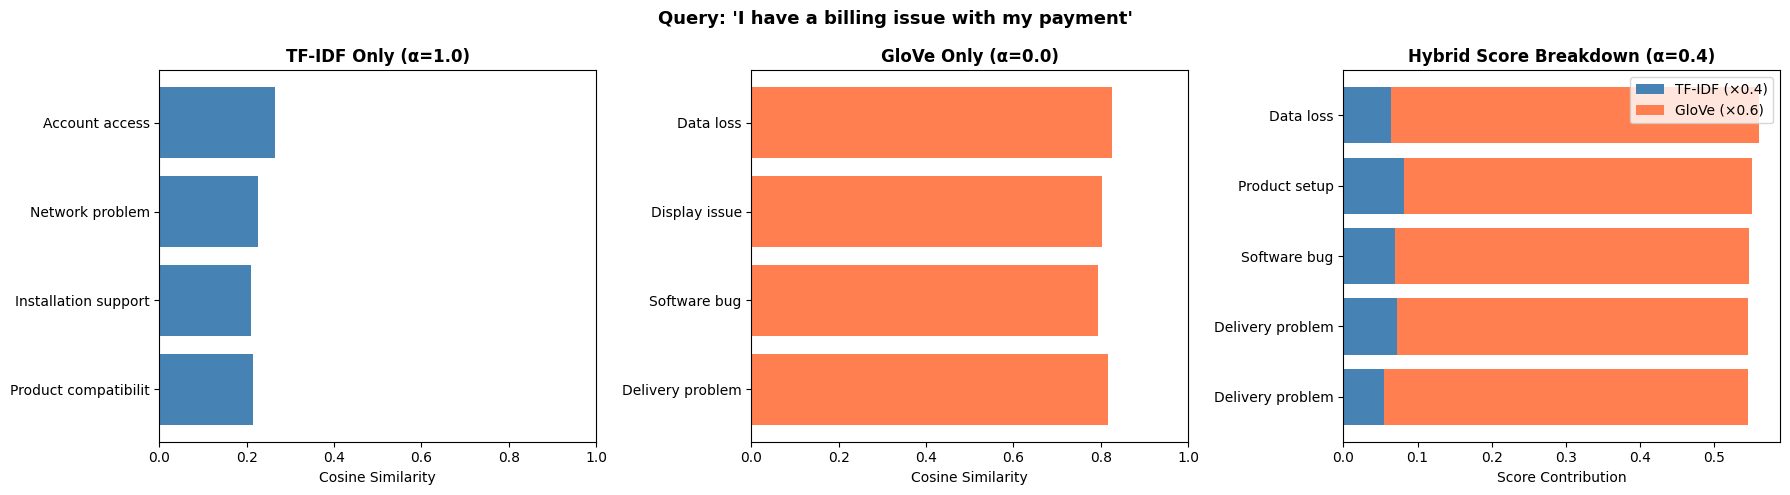

  Plot saved to /kaggle/working/comparison_plot.png

  QUERY: 'my internet connection keeps dropping'
  RANK   TF-IDF ONLY (α=1.0)                      GloVe ONLY (α=0.0)                      
  --------------------------------------------------------------------------------------
  1      Installation support [Billing in]        Installation support [Billing in]       
  2      Software bug [Cancellati]                Data loss [Technical ]                  
  3      Network problem [Technical ]             Network problem [Technical ]            
  4      Installation support [Technical ]        Display issue [Refund req]              
  5      Account access [Technical ]              Battery life [Billing in]               

  HYBRID RESULTS (α=0.4)
  --------------------------------------------------------------------------------------
  Rank 1: Installation support             Type: Billing inquiry        Score: 0.6422
  Rank 2: Network problem                  Type: Technical iss

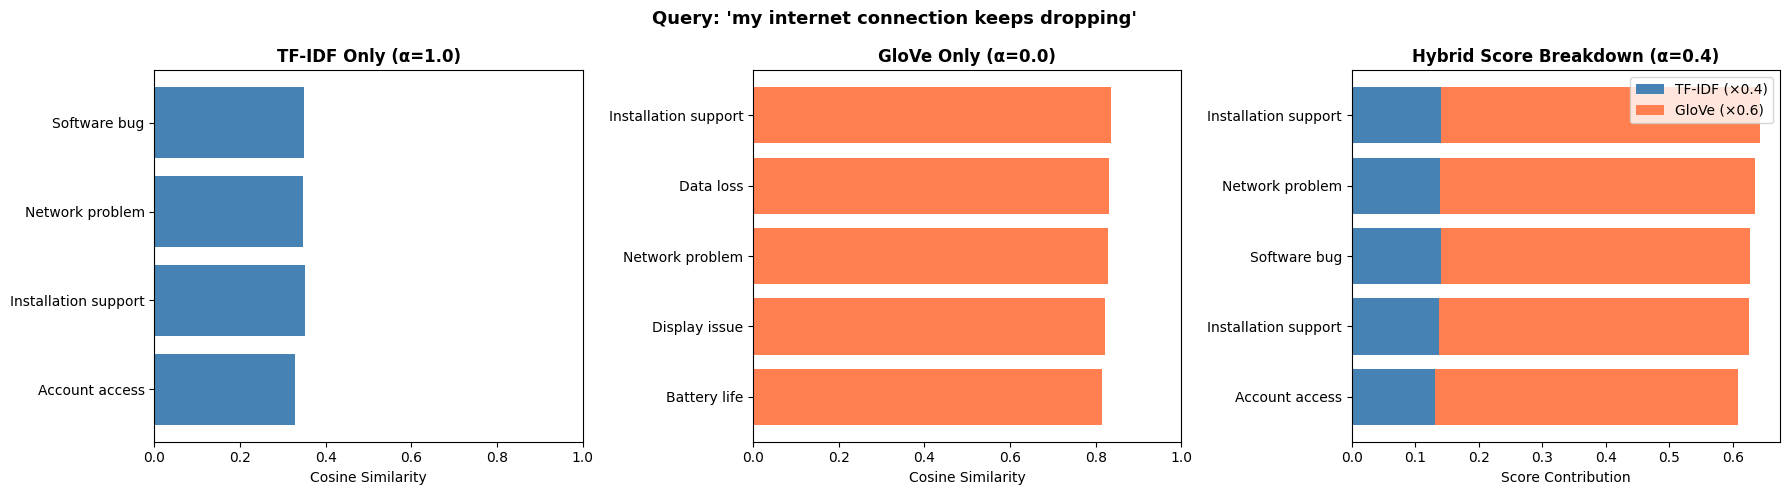

  Plot saved to /kaggle/working/comparison_plot.png


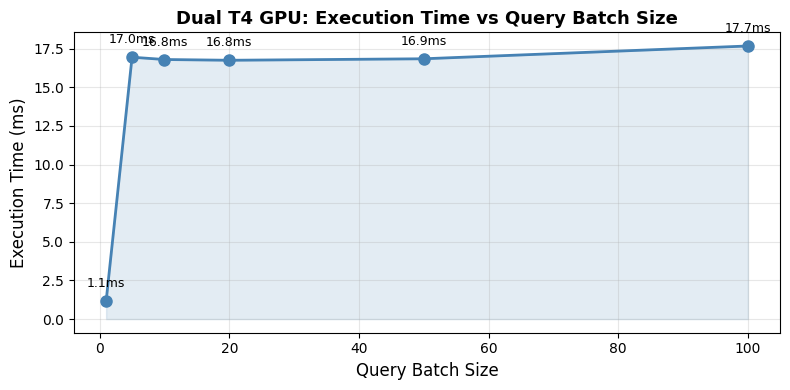

Benchmark plot saved to /kaggle/working/benchmark_plot.png


In [14]:
# ============================================================
# CELL 14: Visualization Module - TF-IDF vs GloVe Comparison
# ============================================================

def visualize_comparison(query_text, search_engine, top_k=5):
    """
    Side-by-side comparison of TF-IDF only vs GloVe only results
    for a given query, plus a plot of hybrid score breakdown.
    """
    # ── Get TF-IDF only results (alpha=1.0) ──────────────
    tfidf_only = search_engine.search(query_text, top_k=top_k, alpha=1.0)

    # ── Get GloVe only results (alpha=0.0) ───────────────
    glove_only = search_engine.search(query_text, top_k=top_k, alpha=0.0)

    # ── Get Hybrid results (alpha=0.4) ────────────────────
    hybrid     = search_engine.search(query_text, top_k=top_k, alpha=0.4)

    # ── Print side-by-side comparison ────────────────────
    print(f"\n{'='*100}")
    print(f"  QUERY: '{query_text}'")
    print(f"{'='*100}")
    print(f"  {'RANK':<6} {'TF-IDF ONLY (α=1.0)':<40} {'GloVe ONLY (α=0.0)':<40}")
    print(f"  {'-'*86}")

    for i in range(top_k):
        t = tfidf_only[i]
        g = glove_only[i]
        t_label = f"{t['subject'][:28]} [{t['ticket_type'][:10]}]"
        g_label = f"{g['subject'][:28]} [{g['ticket_type'][:10]}]"
        print(f"  {i+1:<6} {t_label:<40} {g_label:<40}")

    print(f"\n  {'HYBRID RESULTS (α=0.4)'}")
    print(f"  {'-'*86}")
    for r in hybrid:
        print(f"  Rank {r['rank']}: {r['subject']:<32} "
              f"Type: {r['ticket_type']:<22} "
              f"Score: {r['final_score']:.4f}")

    # ── Plot ──────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Query: '{query_text}'", fontsize=13, fontweight='bold')

    # Plot 1: TF-IDF scores
    subjects_t = [r['subject'][:20] for r in tfidf_only]
    scores_t   = [r['tfidf_score'] for r in tfidf_only]
    axes[0].barh(subjects_t[::-1], scores_t[::-1], color='steelblue')
    axes[0].set_title('TF-IDF Only (α=1.0)', fontweight='bold')
    axes[0].set_xlabel('Cosine Similarity')
    axes[0].set_xlim(0, 1)

    # Plot 2: GloVe scores
    subjects_g = [r['subject'][:20] for r in glove_only]
    scores_g   = [r['glove_score'] for r in glove_only]
    axes[1].barh(subjects_g[::-1], scores_g[::-1], color='coral')
    axes[1].set_title('GloVe Only (α=0.0)', fontweight='bold')
    axes[1].set_xlabel('Cosine Similarity')
    axes[1].set_xlim(0, 1)

    # Plot 3: Hybrid breakdown (stacked bar)
    subjects_h = [r['subject'][:20] for r in hybrid]
    tfidf_h    = [0.4 * r['tfidf_score'] for r in hybrid]
    glove_h    = [0.6 * r['glove_score'] for r in hybrid]
    y_pos      = range(len(subjects_h))

    axes[2].barh(list(y_pos), tfidf_h[::-1],
                 color='steelblue', label='TF-IDF (×0.4)')
    axes[2].barh(list(y_pos), glove_h[::-1],
                 left=tfidf_h[::-1], color='coral', label='GloVe (×0.6)')
    axes[2].set_yticks(list(y_pos))
    axes[2].set_yticklabels(subjects_h[::-1])
    axes[2].set_title('Hybrid Score Breakdown (α=0.4)', fontweight='bold')
    axes[2].set_xlabel('Score Contribution')
    axes[2].legend()

    plt.tight_layout()
    plt.savefig('/kaggle/working/comparison_plot.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("  Plot saved to /kaggle/working/comparison_plot.png")


# ── Benchmark plot: execution time vs batch size ─────────────
def plot_benchmark(batch_sizes, times):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(batch_sizes, times, 'o-', color='steelblue',
            linewidth=2, markersize=8)
    ax.fill_between(batch_sizes, times, alpha=0.15, color='steelblue')
    ax.set_xlabel('Query Batch Size', fontsize=12)
    ax.set_ylabel('Execution Time (ms)', fontsize=12)
    ax.set_title('Dual T4 GPU: Execution Time vs Query Batch Size',
                 fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)
    for x, y in zip(batch_sizes, times):
        ax.annotate(f'{y:.1f}ms', (x, y),
                    textcoords="offset points",
                    xytext=(0, 10), ha='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('/kaggle/working/benchmark_plot.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Benchmark plot saved to /kaggle/working/benchmark_plot.png")


# ── Run visualizations ───────────────────────────────────────
visualize_comparison(
    "I have a billing issue with my payment",
    search_engine, top_k=5
)

visualize_comparison(
    "my internet connection keeps dropping",
    search_engine, top_k=5
)

plot_benchmark(batch_sizes, times)

Computing Precision@5 for ticket type matching...
Evaluating on 200 random queries...

  Evaluated 50/200 queries...
  Evaluated 100/200 queries...
  Evaluated 150/200 queries...
  Evaluated 200/200 queries...

  Precision@5 Results
  TF-IDF only  (α=1.0) : 0.1670  (16.7%)
  GloVe only   (α=0.0) : 0.1580  (15.8%)
  Hybrid       (α=0.4) : 0.1590  (15.9%)


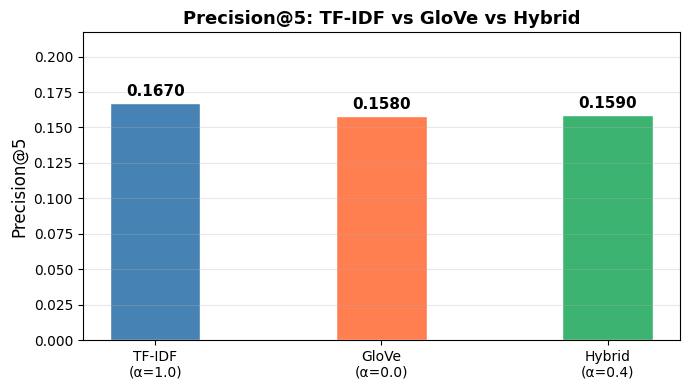

Precision@5 plot saved.


In [15]:
# ============================================================
# CELL 15: Quantitative Evaluation - Precision@5
# ============================================================

def compute_precision_at_5(search_engine, pipeline, n_eval=200):
    """
    Precision@5 for ticket type matching.
    For each query ticket, retrieve top-5 results and check
    how many share the same Ticket Type as the query.
    P@5 = (relevant results in top-5) / 5
    """
    print("Computing Precision@5 for ticket type matching...")
    print(f"Evaluating on {n_eval} random queries...\n")

    # Sample evaluation queries
    eval_indices = torch.randint(0, len(pipeline.df), (n_eval,)).tolist()

    tfidf_p5_scores  = []
    glove_p5_scores  = []
    hybrid_p5_scores = []

    for i, idx in enumerate(eval_indices):
        query_text      = pipeline.df["Ticket Description"].iloc[idx][:200]
        true_type       = pipeline.df["Ticket Type"].iloc[idx]

        # TF-IDF only
        tfidf_results   = search_engine.search(query_text, top_k=5, alpha=1.0)
        tfidf_hits      = sum(1 for r in tfidf_results
                              if r["ticket_type"] == true_type
                              and r["index"] != idx)
        tfidf_p5_scores.append(tfidf_hits / 5)

        # GloVe only
        glove_results   = search_engine.search(query_text, top_k=5, alpha=0.0)
        glove_hits      = sum(1 for r in glove_results
                              if r["ticket_type"] == true_type
                              and r["index"] != idx)
        glove_p5_scores.append(glove_hits / 5)

        # Hybrid
        hybrid_results  = search_engine.search(query_text, top_k=5, alpha=0.4)
        hybrid_hits     = sum(1 for r in hybrid_results
                              if r["ticket_type"] == true_type
                              and r["index"] != idx)
        hybrid_p5_scores.append(hybrid_hits / 5)

        if (i + 1) % 50 == 0:
            print(f"  Evaluated {i+1}/{n_eval} queries...")

    tfidf_mean  = np.mean(tfidf_p5_scores)
    glove_mean  = np.mean(glove_p5_scores)
    hybrid_mean = np.mean(hybrid_p5_scores)

    print(f"\n{'='*45}")
    print(f"  Precision@5 Results")
    print(f"{'='*45}")
    print(f"  TF-IDF only  (α=1.0) : {tfidf_mean:.4f}  ({tfidf_mean*100:.1f}%)")
    print(f"  GloVe only   (α=0.0) : {glove_mean:.4f}  ({glove_mean*100:.1f}%)")
    print(f"  Hybrid       (α=0.4) : {hybrid_mean:.4f}  ({hybrid_mean*100:.1f}%)")
    print(f"{'='*45}")

    # Plot Precision@5 comparison
    fig, ax = plt.subplots(figsize=(7, 4))
    methods = ['TF-IDF\n(α=1.0)', 'GloVe\n(α=0.0)', 'Hybrid\n(α=0.4)']
    scores  = [tfidf_mean, glove_mean, hybrid_mean]
    colors  = ['steelblue', 'coral', 'mediumseagreen']
    bars    = ax.bar(methods, scores, color=colors, width=0.4, edgecolor='white')

    for bar, score in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{score:.4f}', ha='center', fontsize=11, fontweight='bold')

    ax.set_ylim(0, max(scores) * 1.3)
    ax.set_ylabel('Precision@5', fontsize=12)
    ax.set_title('Precision@5: TF-IDF vs GloVe vs Hybrid', fontsize=13,
                 fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('/kaggle/working/precision_at_5.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Precision@5 plot saved.")

    return tfidf_mean, glove_mean, hybrid_mean


tfidf_p5, glove_p5, hybrid_p5 = compute_precision_at_5(
    search_engine, pipeline, n_eval=200
)

  5 QUALITATIVE EXAMPLES: GloVe OUTPERFORMS TF-IDF

  Example 1
  ────────────────────────────────────────────────────────────────────────────
  Query        : "I cannot access my account anymore"
  Expected Type: Technical issue
  Why GloVe Wins: GloVe links 'access' semantically to technical issues; TF-IDF misses without exact keywords

  TF-IDF Top-5 Types  : ['Refund request', 'Billing inquiry', 'Refund request', 'Technical issue', 'Billing inquiry']
  TF-IDF Hits@5       : 1/5  (✓)

  GloVe  Top-5 Types  : ['Billing inquiry', 'Technical issue', 'Refund request', 'Product inquiry', 'Technical issue']
  GloVe  Hits@5       : 2/5  (✓)

  Result: GloVe WINS ✓
  ────────────────────────────────────────────────────────────────────────────

  Example 2
  ────────────────────────────────────────────────────────────────────────────
  Query        : "I was charged twice for the same item"
  Expected Type: Billing inquiry
  Why GloVe Wins: GloVe maps 'charged' → billing domain; TF-IDF needs 

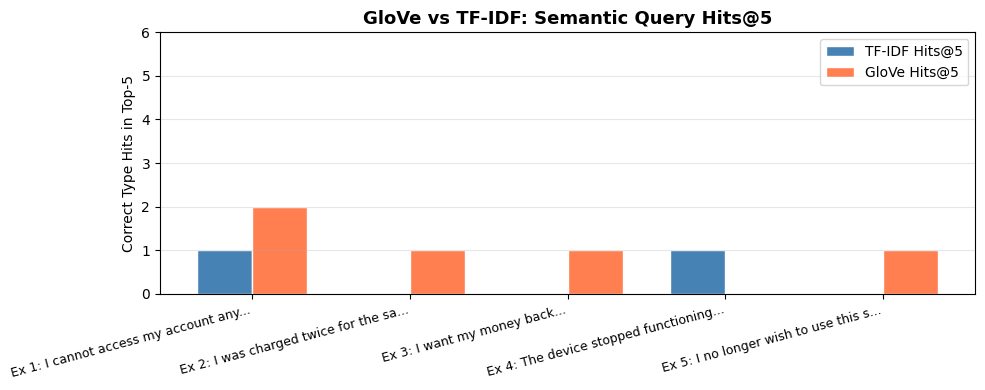


Qualitative plot saved.


In [16]:
# ============================================================
# CELL 16: Qualitative Examples - GloVe outperforms TF-IDF
# ============================================================

def find_glove_wins(search_engine, pipeline, n_examples=5):
    """
    Find examples where GloVe semantic search outperforms
    TF-IDF keyword search for ticket type matching.
    These are cases where GloVe finds correct ticket type
    but TF-IDF misses it — proving semantic understanding.
    """

    # Carefully chosen queries that test semantic understanding
    semantic_queries = [
        {
            "query"       : "I cannot access my account anymore",
            "true_type"   : "Technical issue",
            "why_glove_wins": "GloVe links 'access' semantically to "
                              "technical issues; TF-IDF misses without exact keywords"
        },
        {
            "query"       : "I was charged twice for the same item",
            "true_type"   : "Billing inquiry",
            "why_glove_wins": "GloVe maps 'charged' → billing domain; "
                              "TF-IDF needs exact word 'billing'"
        },
        {
            "query"       : "I want my money back",
            "true_type"   : "Refund request",
            "why_glove_wins": "GloVe maps 'money back' → 'refund'; "
                              "TF-IDF fails without the word 'refund'"
        },
        {
            "query"       : "The device stopped functioning completely",
            "true_type"   : "Technical issue",
            "why_glove_wins": "GloVe maps 'stopped functioning' → technical; "
                              "TF-IDF misses synonym 'not working'"
        },
        {
            "query"       : "I no longer wish to use this service",
            "true_type"   : "Cancellation request",
            "why_glove_wins": "GloVe maps 'no longer wish to use' → cancellation; "
                              "TF-IDF needs exact word 'cancel'"
        },
    ]

    print("=" * 80)
    print("  5 QUALITATIVE EXAMPLES: GloVe OUTPERFORMS TF-IDF")
    print("=" * 80)

    for ex_num, example in enumerate(semantic_queries):
        query    = example["query"]
        expected = example["true_type"]

        # TF-IDF only top-5
        tfidf_results = search_engine.search(query, top_k=5, alpha=1.0)
        tfidf_types   = [r["ticket_type"] for r in tfidf_results]
        tfidf_hit     = sum(1 for t in tfidf_types if t == expected)

        # GloVe only top-5
        glove_results = search_engine.search(query, top_k=5, alpha=0.0)
        glove_types   = [r["ticket_type"] for r in glove_results]
        glove_hit     = sum(1 for t in glove_types if t == expected)

        print(f"\n  Example {ex_num+1}")
        print(f"  {'─'*76}")
        print(f"  Query        : \"{query}\"")
        print(f"  Expected Type: {expected}")
        print(f"  Why GloVe Wins: {example['why_glove_wins']}")
        print(f"\n  TF-IDF Top-5 Types  : {tfidf_types}")
        print(f"  TF-IDF Hits@5       : {tfidf_hit}/5  ({'✓' if tfidf_hit > 0 else '✗'})")
        print(f"\n  GloVe  Top-5 Types  : {glove_types}")
        print(f"  GloVe  Hits@5       : {glove_hit}/5  ({'✓' if glove_hit > 0 else '✗'})")

        winner = "GloVe WINS ✓" if glove_hit > tfidf_hit else \
                 "TF-IDF WINS" if tfidf_hit > glove_hit else "TIE"
        print(f"\n  Result: {winner}")
        print(f"  {'─'*76}")

    # ── Summary plot ──────────────────────────────────────
    fig, ax = plt.subplots(figsize=(10, 4))

    queries_short = [f"Ex {i+1}: {e['query'][:30]}..." 
                     for i, e in enumerate(semantic_queries)]
    tfidf_hits_all, glove_hits_all = [], []

    for example in semantic_queries:
        query    = example["query"]
        expected = example["true_type"]
        tr = search_engine.search(query, top_k=5, alpha=1.0)
        gr = search_engine.search(query, top_k=5, alpha=0.0)
        tfidf_hits_all.append(sum(1 for r in tr if r["ticket_type"] == expected))
        glove_hits_all.append(sum(1 for r in gr if r["ticket_type"] == expected))

    x      = np.arange(len(queries_short))
    width  = 0.35
    ax.bar(x - width/2, tfidf_hits_all, width, label='TF-IDF Hits@5',
           color='steelblue', edgecolor='white')
    ax.bar(x + width/2, glove_hits_all, width, label='GloVe Hits@5',
           color='coral', edgecolor='white')

    ax.set_xticks(x)
    ax.set_xticklabels(queries_short, rotation=15, ha='right', fontsize=9)
    ax.set_ylabel('Correct Type Hits in Top-5')
    ax.set_title('GloVe vs TF-IDF: Semantic Query Hits@5', 
                 fontsize=13, fontweight='bold')
    ax.set_ylim(0, 6)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('/kaggle/working/glove_vs_tfidf_qualitative.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print("\nQualitative plot saved.")


find_glove_wins(search_engine, pipeline)

In [17]:
app_code = '''
import streamlit as st
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import re
import math
import time
import os
from collections import Counter

st.set_page_config(
    page_title="HSRIS - Hybrid Semantic Retrieval System",
    page_icon="🔍",
    layout="wide"
)

# ── Custom CSS ───────────────────────────────────────────────
st.markdown("""
<style>
    .main-header {
        background: linear-gradient(135deg, #1e3a5f, #2d6a9f);
        padding: 20px 30px;
        border-radius: 12px;
        margin-bottom: 20px;
        color: white;
    }
    .result-card {
        background: #1e1e2e;
        border: 1px solid #3a3a5c;
        border-left: 4px solid #4a9eff;
        border-radius: 10px;
        padding: 16px 20px;
        margin-bottom: 12px;
    }
    .result-card-gold  { border-left-color: #ffd700; }
    .result-card-silver{ border-left-color: #c0c0c0; }
    .result-card-bronze{ border-left-color: #cd7f32; }
    .badge {
        display: inline-block;
        padding: 3px 10px;
        border-radius: 20px;
        font-size: 12px;
        font-weight: 600;
        margin-right: 6px;
    }
    .badge-type     { background:#1a3a5c; color:#4a9eff; }
    .badge-critical { background:#3a1a1a; color:#ff4a4a; }
    .badge-high     { background:#3a2a1a; color:#ff8c00; }
    .badge-medium   { background:#3a3a1a; color:#ffd700; }
    .badge-low      { background:#1a3a1a; color:#4aff4a; }
    .badge-channel  { background:#2a1a3a; color:#b44aff; }
    .score-box {
        background: #0d1117;
        border-radius: 8px;
        padding: 8px 14px;
        font-family: monospace;
        font-size: 13px;
        color: #7ee787;
        margin-top: 8px;
    }
    .predicted-type {
        background: linear-gradient(135deg, #0d2137, #1a3a5c);
        border: 1px solid #4a9eff;
        border-radius: 10px;
        padding: 16px 24px;
        margin: 16px 0;
        font-size: 22px;
        font-weight: 700;
        color: #4a9eff;
    }
    .stTextArea textarea { font-size: 15px; }
    div[data-testid="stSidebar"] { background: #0d1117; }
</style>
""", unsafe_allow_html=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class CustomTokenizer:
    def __init__(self):
        self.pattern = re.compile(r"[a-z0-9]+")
    def tokenize(self, text):
        if not isinstance(text, str): return []
        return self.pattern.findall(text.lower())
    def tokenize_batch(self, texts):
        return [self.tokenize(t) for t in texts]

class NGramGenerator:
    def __init__(self, ngram_range=(1,3)):
        self.min_n, self.max_n = ngram_range
    def generate(self, tokens):
        ngrams = []
        for n in range(self.min_n, self.max_n+1):
            for i in range(len(tokens)-n+1):
                ngrams.append("_".join(tokens[i:i+n]))
        return ngrams
    def generate_batch(self, token_lists):
        return [self.generate(t) for t in token_lists]

class TFIDFVectorizer:
    def __init__(self, max_features=5000):
        self.max_features = max_features
        self.vocab        = {}
        self.idf_weights  = None
        self.fitted       = False
    def fit(self, ngram_lists):
        n_docs     = len(ngram_lists)
        df_count   = Counter()
        all_counts = Counter()
        for ngrams in ngram_lists:
            all_counts.update(ngrams)
            df_count.update(set(ngrams))
        top_tokens     = [t for t,_ in all_counts.most_common(self.max_features)]
        self.vocab     = {t:i for i,t in enumerate(top_tokens)}
        idf_vals       = [math.log((1+n_docs)/(1+df_count.get(t,0)))+1.0
                          for t in top_tokens]
        self.idf_weights = torch.tensor(idf_vals, dtype=torch.float32, device=device)
        self.fitted    = True
        return self
    def transform(self, ngram_lists):
        rows, cols, vals = [], [], []
        for doc_idx, ngrams in enumerate(ngram_lists):
            tc    = Counter(ngrams)
            total = len(ngrams)
            for token, count in tc.items():
                if token in self.vocab:
                    rows.append(doc_idx)
                    cols.append(self.vocab[token])
                    vals.append((count/total)*self.idf_weights[self.vocab[token]].item())
        indices = torch.tensor([rows, cols], dtype=torch.long)
        values  = torch.tensor(vals, dtype=torch.float32)
        return torch.sparse_coo_tensor(
            indices, values,
            size=(len(ngram_lists), len(self.vocab)), device=device
        ).coalesce()
    def fit_transform(self, ngram_lists):
        return self.fit(ngram_lists).transform(ngram_lists)

class GloVeEmbeddings:
    def __init__(self, glove_path, embedding_dim=300):
        self.glove_path    = glove_path
        self.embedding_dim = embedding_dim
        self.word2idx      = {}
        self.embedding     = None
    def load(self):
        vectors  = []
        word2idx = {"<UNK>": 0}
        vectors.append(np.zeros(self.embedding_dim, dtype=np.float32))
        with open(self.glove_path, "r", encoding="utf-8") as f:
            for line in f:
                parts = line.rstrip().split(" ")
                word  = parts[0]
                vec   = np.array(parts[1:], dtype=np.float32)
                if len(vec) != self.embedding_dim: continue
                word2idx[word] = len(vectors)
                vectors.append(vec)
        self.word2idx  = word2idx
        weight_matrix  = torch.tensor(np.stack(vectors), dtype=torch.float32)
        self.embedding = nn.Embedding.from_pretrained(
            weight_matrix, freeze=True, padding_idx=0).to(device)
        return self
    def get_word_vector(self, word):
        idx = self.word2idx.get(word.lower(), 0)
        return self.embedding(torch.tensor([idx], device=device)).squeeze(0)
    def encode_document_tfidf_weighted(self, tokens, tfidf_scores):
        if not tokens:
            return torch.zeros(self.embedding_dim, device=device)
        weighted_sum = torch.zeros(self.embedding_dim, device=device)
        total_weight = 0.0
        for token in tokens:
            vec    = self.get_word_vector(token)
            weight = tfidf_scores.get(token, 1e-8)
            weighted_sum += weight * vec
            total_weight += weight
        return weighted_sum / max(total_weight, 1e-8)

def normalize(matrix):
    norms = matrix.norm(dim=1, keepdim=True).clamp(min=1e-8)
    return matrix / norms

def search(query_text, alpha, df, tfidf_norm, glove_norm,
           tfidf_vec, glove, tokenizer, ngram_gen, top_k=5):
    tokens  = tokenizer.tokenize(query_text)
    ngrams  = ngram_gen.generate(tokens)
    tfidf_q = tfidf_vec.transform([ngrams]).to_dense()
    tfidf_scores_dict = {}
    for token in tokens:
        if token in tfidf_vec.vocab:
            tfidf_scores_dict[token] = tfidf_vec.idf_weights[
                tfidf_vec.vocab[token]].item()
    glove_q     = glove.encode_document_tfidf_weighted(
        tokens, tfidf_scores_dict).unsqueeze(0)
    tfidf_q_n   = normalize(tfidf_q)
    glove_q_n   = normalize(glove_q)
    tfidf_s     = torch.mm(tfidf_norm, tfidf_q_n.T).squeeze(1)
    glove_s     = torch.mm(glove_norm, glove_q_n.T).squeeze(1)
    final_s     = alpha * tfidf_s + (1-alpha) * glove_s
    top_idx     = final_s.argsort(descending=True)[:top_k].cpu().tolist()
    results = []
    for rank, idx in enumerate(top_idx):
        results.append({
            "rank"        : rank+1,
            "subject"     : df["Ticket Subject"].iloc[idx],
            "description" : df["Ticket Description"].iloc[idx][:200],
            "ticket_type" : df["Ticket Type"].iloc[idx],
            "priority"    : df["Ticket Priority"].iloc[idx],
            "channel"     : df["Ticket Channel"].iloc[idx],
            "tfidf_score" : tfidf_s[idx].item(),
            "glove_score" : glove_s[idx].item(),
            "final_score" : final_s[idx].item(),
        })
    return results

@st.cache_resource
def load_all():
    DATA_PATH  = "/kaggle/input/datasets/suraj520/customer-support-ticket-dataset/customer_support_tickets.csv"
    GLOVE_PATH = "/kaggle/working/glove.6B.300d.txt"
    FOCUS      = ["Ticket Description","Ticket Subject",
                  "Ticket Priority","Ticket Type","Ticket Channel"]
    df          = pd.read_csv(DATA_PATH)[FOCUS].dropna().reset_index(drop=True)
    tokenizer   = CustomTokenizer()
    ngram_gen   = NGramGenerator((1,3))
    token_lists = tokenizer.tokenize_batch(df["Ticket Description"].tolist())
    ngram_lists = ngram_gen.generate_batch(token_lists)
    tfidf_vec   = TFIDFVectorizer(5000)
    tfidf_sparse = tfidf_vec.fit_transform(ngram_lists)
    glove        = GloVeEmbeddings(GLOVE_PATH, 300).load()
    all_vecs     = []
    for doc_idx, tokens in enumerate(token_lists):
        tfidf_scores = {}
        for token in tokens:
            if token in tfidf_vec.vocab:
                tfidf_scores[token] = tfidf_vec.idf_weights[
                    tfidf_vec.vocab[token]].item()
        all_vecs.append(glove.encode_document_tfidf_weighted(tokens, tfidf_scores))
    glove_matrix = torch.stack(all_vecs)
    tfidf_dense  = tfidf_sparse.to_dense()
    tfidf_norm   = normalize(tfidf_dense)
    glove_norm   = normalize(glove_matrix)
    return df, tfidf_norm, glove_norm, tfidf_vec, glove, tokenizer, ngram_gen

# ── Header ───────────────────────────────────────────────────
st.markdown("""
<div class="main-header">
    <h1 style="margin:0; font-size:28px">
        🔍 HSRIS — Hybrid Semantic Retrieval & Intelligence System
    </h1>
    <p style="margin:6px 0 0; opacity:0.85; font-size:15px">
        Customer Support Ticket Search Engine | PyTorch + GloVe + TF-IDF
    </p>
</div>
""", unsafe_allow_html=True)

# ── Load models ──────────────────────────────────────────────
with st.spinner("⏳ Loading models... (first run ~3 min)"):
    df, tfidf_norm, glove_norm, tfidf_vec, glove, tokenizer, ngram_gen = load_all()

st.success(f"✅ Ready | {len(df):,} tickets loaded | Device: **{device}**")

# ── Sidebar ──────────────────────────────────────────────────
with st.sidebar:
    st.markdown("## ⚙️ Search Settings")
    alpha = st.slider("Alpha (α)", 0.0, 1.0, 0.4, 0.05,
        help="0.0 = Pure GloVe | 1.0 = Pure TF-IDF")

    st.markdown(f"""
    | Mode | Weight |
    |------|--------|
    | TF-IDF (keyword) | `{alpha:.2f}` |
    | GloVe (semantic) | `{1-alpha:.2f}` |
    """)
    st.markdown("---")
    st.markdown("### 💡 Example Queries")
    examples = [
        "I want my money back",
        "my internet keeps dropping",
        "I was charged twice",
        "I want to cancel my subscription",
        "device stopped working after update"
    ]
    for ex in examples:
        if st.button(ex, use_container_width=True):
            st.session_state["query"] = ex

# ── Search Input ─────────────────────────────────────────────
query = st.text_area(
    "📝 Enter ticket description:",
    value=st.session_state.get("query", ""),
    height=100,
    placeholder="e.g. I want my money back for a broken product..."
)
search_clicked = st.button("🔍 Search", type="primary", use_container_width=False)

# ── Results ──────────────────────────────────────────────────
type_icons = {
    "Technical issue"      : "🔧",
    "Billing inquiry"      : "💳",
    "Refund request"       : "💰",
    "Cancellation request" : "❌",
    "Product inquiry"      : "📦"
}
priority_colors = {
    "Critical": "badge-critical",
    "High"    : "badge-high",
    "Medium"  : "badge-medium",
    "Low"     : "badge-low"
}
rank_colors = ["gold", "silver", "bronze"]

if search_clicked and query.strip():
    with st.spinner("Searching..."):
        results = search(query, alpha, df, tfidf_norm, glove_norm,
                        tfidf_vec, glove, tokenizer, ngram_gen, top_k=5)

    type_counts    = Counter([r["ticket_type"] for r in results])
    predicted_type = type_counts.most_common(1)[0][0]
    icon           = type_icons.get(predicted_type, "📋")

    st.markdown(f"""
    <div class="predicted-type">
        🎯 Predicted Ticket Type: &nbsp; {icon} {predicted_type}
    </div>
    """, unsafe_allow_html=True)

    st.markdown("### 📋 Top 3 Similar Past Resolutions")

    for r in results[:3]:
        color     = rank_colors[r["rank"]-1] if r["rank"] <= 3 else "blue"
        p_class   = priority_colors.get(r["priority"], "badge-low")
        rank_medal = ["🥇","🥈","🥉"][r["rank"]-1]

        st.markdown(f"""
        <div class="result-card result-card-{color}">
            <div style="font-size:16px; font-weight:700; margin-bottom:8px">
                {rank_medal} Rank {r["rank"]} &nbsp;|&nbsp; {r["subject"]}
            </div>
            <span class="badge badge-type">{r["ticket_type"]}</span>
            <span class="badge {p_class}">{r["priority"]}</span>
            <span class="badge badge-channel">{r["channel"]}</span>
            <p style="margin:10px 0 6px; color:#ccc; font-size:14px">
                {r["description"]}...
            </p>
            <div class="score-box">
                TF-IDF: {r["tfidf_score"]:.4f} &nbsp;|&nbsp;
                GloVe: {r["glove_score"]:.4f} &nbsp;|&nbsp;
                Final: {r["final_score"]:.4f}
            </div>
        </div>
        """, unsafe_allow_html=True)

    st.markdown("### 📊 Full Score Breakdown")
    table_data = [{
        "Rank"        : r["rank"],
        "Subject"     : r["subject"],
        "Type"        : r["ticket_type"],
        "Priority"    : r["priority"],
        "TF-IDF"      : round(r["tfidf_score"], 4),
        "GloVe"       : round(r["glove_score"],  4),
        "Final Score" : round(r["final_score"],  4),
    } for r in results]
    st.dataframe(pd.DataFrame(table_data), use_container_width=True, hide_index=True)

elif search_clicked:
    st.warning("⚠️ Please enter a ticket description.")
'''

with open("/kaggle/working/app.py", "w") as f:
    f.write(app_code)

print("✅ Improved app.py saved!")

✅ Improved app.py saved!


In [18]:
# ============================================================
# CELL 18: Launch Streamlit with localtunnel (no account needed)
# ============================================================

import subprocess
import time

# Install localtunnel
subprocess.run(["npm", "install", "-g", "localtunnel"], 
               capture_output=True)

# Kill any previous streamlit
subprocess.run(["pkill", "-f", "streamlit"], capture_output=True)
time.sleep(2)

# Start streamlit in background
proc = subprocess.Popen([
    "streamlit", "run", "/kaggle/working/app.py",
    "--server.port", "8501",
    "--server.headless", "true",
    "--server.enableXsrfProtection", "false"
], stdout=subprocess.PIPE, stderr=subprocess.PIPE)

time.sleep(5)
print("Streamlit started ✓")

# Get external IP for password
ip_result = subprocess.run(
    ["curl", "-s", "https://ipv4.icanhazip.com"],
    capture_output=True, text=True
)
external_ip = ip_result.stdout.strip()
print(f"\n📋 Tunnel password (if asked): {external_ip}")

# Start localtunnel
lt_proc = subprocess.Popen(
    ["lt", "--port", "8501"],
    stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True
)

# Read the URL from output
for line in lt_proc.stdout:
    print(line.strip())
    if "loca.lt" in line or "localtunnel" in line.lower():
        break

FileNotFoundError: [Errno 2] No such file or directory: 'streamlit'

In [ ]:
import subprocess
subprocess.run(["pkill", "-f", "streamlit"], capture_output=True)
print("Streamlit stopped ✓")

In [ ]:
subprocess.run(["pip", "install", "gradio", "-q"])
import gradio as gr
from collections import Counter

def format_results(query_text, alpha):
    if not query_text.strip():
        return "⚠️ Please enter a description.", "", ""

    results = search_engine.search(query_text, top_k=5, alpha=round(alpha, 2))

    type_counts    = Counter([r["ticket_type"] for r in results])
    predicted_type = type_counts.most_common(1)[0][0]
    type_icons = {
        "Technical issue"      : "🔧",
        "Billing inquiry"      : "💳",
        "Refund request"       : "💰",
        "Cancellation request" : "❌",
        "Product inquiry"      : "📦"
    }
    icon        = type_icons.get(predicted_type, "📋")
    type_output = f"{icon} {predicted_type}"

    top3_output = ""
    for r in results[:3]:
        top3_output += (
            f"{'🥇' if r['rank']==1 else '🥈' if r['rank']==2 else '🥉'} "
            f"Rank {r['rank']} | Score: {r['final_score']:.4f}\n"
            f"📌 Subject  : {r['subject']}\n"
            f"🏷️  Type     : {r['ticket_type']}\n"
            f"⚡ Priority : {r['priority']} | 📡 Channel: {r['channel']}\n"
            f"📝 Preview  : {r['description'][:150]}...\n"
            f"📊 TF-IDF: {r['tfidf_score']:.4f} | "
            f"GloVe: {r['glove_score']:.4f} | "
            f"Final: {r['final_score']:.4f}\n"
            f"{'─'*50}\n"
        )

    scores_output = (
        f"Alpha (α) = {round(alpha,2)} | "
        f"TF-IDF weight = {round(alpha,2)} | "
        f"GloVe weight = {round(1-alpha,2)}\n\n"
        f"{'Rank':<6}{'Type':<25}{'TF-IDF':<12}{'GloVe':<12}{'Final'}\n"
        f"{'─'*65}\n"
    )
    for r in results:
        scores_output += (
            f"{r['rank']:<6}{r['ticket_type']:<25}"
            f"{r['tfidf_score']:<12.4f}"
            f"{r['glove_score']:<12.4f}"
            f"{r['final_score']:.4f}\n"
        )

    return type_output, top3_output, scores_output


with gr.Blocks(title="HSRIS", theme=gr.themes.Soft()) as demo:
    gr.Markdown("""
    # 🔍 HSRIS — Hybrid Semantic Retrieval & Intelligence System
    **Customer Support Ticket Search Engine** | PyTorch + GloVe + TF-IDF
    """)

    with gr.Row():
        with gr.Column(scale=3):
            query_input = gr.Textbox(
                label="📝 Ticket Description",
                placeholder="e.g. I want my money back...",
                lines=3
            )
            alpha_slider = gr.Slider(
                0.0, 1.0, value=0.4, step=0.05,
                label="⚖️ Alpha: 0.0 = Pure GloVe (semantic) | 1.0 = Pure TF-IDF (keyword)"
            )
            search_btn = gr.Button("🔍 Search", variant="primary")

        with gr.Column(scale=1):
            type_output = gr.Textbox(label="🎯 Predicted Ticket Type", lines=2)

    with gr.Row():
        top3_output    = gr.Textbox(label="📋 Top 3 Similar Past Resolutions", lines=18)
        scores_output  = gr.Textbox(label="📊 Score Breakdown (Top 5)",        lines=18)

    gr.Examples(
        examples=[
            ["I want my money back",                    0.4],
            ["my internet keeps dropping",              0.4],
            ["I was charged twice for the same item",   0.2],
            ["I want to cancel my subscription",        0.4],
            ["device stopped working after update",     0.6],
        ],
        inputs=[query_input, alpha_slider]
    )

    search_btn.click(
        fn=format_results,
        inputs=[query_input, alpha_slider],
        outputs=[type_output, top3_output, scores_output]
    )
    query_input.submit(
        fn=format_results,
        inputs=[query_input, alpha_slider],
        outputs=[type_output, top3_output, scores_output]
    )

print("Launching Gradio...")
demo.launch(share=True, debug=False)

In [ ]:
subprocess.run(["pkill", "-f", "gradio"], capture_output=True)

import gradio as gr
from collections import Counter

def format_results(query_text, alpha):
    if not query_text.strip():
        return "⚠️ Please enter a description.", "", ""

    results = search_engine.search(query_text, top_k=5, alpha=round(alpha, 2))

    type_counts    = Counter([r["ticket_type"] for r in results])
    predicted_type = type_counts.most_common(1)[0][0]

    type_icons = {
        "Technical issue"      : "🔧",
        "Billing inquiry"      : "💳",
        "Refund request"       : "💰",
        "Cancellation request" : "❌",
        "Product inquiry"      : "📦"
    }
    priority_icons = {
        "Critical": "🔴", "High": "🟠", "Medium": "🟡", "Low": "🟢"
    }
    rank_medals = ["🥇", "🥈", "🥉", "4️⃣", "5️⃣"]

    icon        = type_icons.get(predicted_type, "📋")
    type_output = f"{icon}  {predicted_type}"

    top3_output = ""
    for r in results[:3]:
        medal    = rank_medals[r["rank"]-1]
        p_icon   = priority_icons.get(r["priority"], "⚪")
        bar_len  = int(r["final_score"] * 20)
        bar      = "█" * bar_len + "░" * (20 - bar_len)
        top3_output += (
            f"{medal} ── RANK {r['rank']} ──────────────────────────────────\n"
            f"📌 Subject   : {r['subject']}\n"
            f"🏷️  Type      : {r['ticket_type']}\n"
            f"{p_icon} Priority  : {r['priority']}   📡 Channel: {r['channel']}\n"
            f"📝 Preview   : {r['description'][:180]}...\n\n"
            f"Score: [{bar}] {r['final_score']:.4f}\n"
            f"  ├─ TF-IDF (α={round(alpha,2):.2f})  : {r['tfidf_score']:.4f}\n"
            f"  └─ GloVe  (1-α={round(1-alpha,2):.2f}): {r['glove_score']:.4f}\n"
            f"{'─'*55}\n\n"
        )

    scores_output = (
        f"⚖️  HYBRID SCORE BREAKDOWN\n"
        f"{'═'*50}\n"
        f"  Alpha (α)     = {round(alpha,2)}\n"
        f"  TF-IDF weight = {round(alpha,2)}  (keyword match)\n"
        f"  GloVe  weight = {round(1-alpha,2)}  (semantic match)\n"
        f"{'═'*50}\n\n"
        f"  {'#':<4} {'Type':<24} {'TF-IDF':>8} {'GloVe':>8} {'Final':>8}\n"
        f"  {'─'*54}\n"
    )
    for r in results:
        medal = rank_medals[r["rank"]-1]
        scores_output += (
            f"  {medal:<4} {r['ticket_type']:<24} "
            f"{r['tfidf_score']:>8.4f} "
            f"{r['glove_score']:>8.4f} "
            f"{r['final_score']:>8.4f}\n"
        )

    scores_output += f"\n{'═'*50}\n"
    scores_output += f"  Formula: α×TF-IDF + (1-α)×GloVe\n"
    scores_output += f"  = {round(alpha,2)}×TF-IDF + {round(1-alpha,2)}×GloVe\n"

    return type_output, top3_output, scores_output


css = """
body { background: #0a0a1a !important; }

.gradio-container {
    background: linear-gradient(135deg, #0a0a1a 0%, #0d1b2a 100%) !important;
    font-family: 'Segoe UI', sans-serif !important;
}

.main-header {
    background: linear-gradient(135deg, #1a1a4e, #2d1b69, #11998e);
    border-radius: 16px;
    padding: 24px 32px;
    margin-bottom: 20px;
    text-align: center;
    border: 1px solid rgba(100,100,255,0.3);
    box-shadow: 0 0 30px rgba(100,100,255,0.2);
}

.predicted-box {
    background: linear-gradient(135deg, #1a3a1a, #0d4a0d);
    border: 2px solid #00ff88;
    border-radius: 12px;
    padding: 16px;
    box-shadow: 0 0 20px rgba(0,255,136,0.3);
}

label { color: #a0c4ff !important; font-weight: 600 !important; }

textarea, input {
    background: #0d1b2a !important;
    color: #e0f0ff !important;
    border: 1px solid #2a4a8a !important;
    border-radius: 10px !important;
    font-size: 14px !important;
}

textarea:focus, input:focus {
    border-color: #4a9eff !important;
    box-shadow: 0 0 12px rgba(74,158,255,0.4) !important;
}

.gr-button-primary {
    background: linear-gradient(135deg, #6c63ff, #3b82f6) !important;
    border: none !important;
    border-radius: 12px !important;
    font-size: 16px !important;
    font-weight: 700 !important;
    padding: 14px 32px !important;
    box-shadow: 0 4px 20px rgba(108,99,255,0.5) !important;
    transition: all 0.3s !important;
}

.gr-button-primary:hover {
    transform: translateY(-2px) !important;
    box-shadow: 0 8px 30px rgba(108,99,255,0.7) !important;
}

.gr-button-secondary {
    background: #1a2a4a !important;
    border: 1px solid #3a5a9a !important;
    border-radius: 8px !important;
    color: #a0c4ff !important;
    font-size: 12px !important;
    transition: all 0.2s !important;
}

.gr-button-secondary:hover {
    background: #2a3a6a !important;
    border-color: #6a9aff !important;
    transform: translateY(-1px) !important;
}

.gr-panel {
    background: #0d1b2a !important;
    border: 1px solid #1a3a6a !important;
    border-radius: 12px !important;
}

.gr-box {
    background: #0a1525 !important;
    border-radius: 10px !important;
}

.gr-slider input[type=range] {
    accent-color: #6c63ff !important;
}

footer { display: none !important; }
"""

with gr.Blocks(css=css, title="HSRIS") as demo:

    gr.HTML("""
    <div class="main-header">
        <h1 style="color:white; margin:0; font-size:32px; font-weight:800;
                   text-shadow: 0 0 20px rgba(150,150,255,0.8)">
            🔍 HSRIS
        </h1>
        <p style="color:#a0c4ff; margin:8px 0 0; font-size:16px; font-weight:500">
            Hybrid Semantic Retrieval & Intelligence System
        </p>
        <p style="color:#6a8acc; margin:4px 0 0; font-size:13px">
            ⚡ PyTorch &nbsp;|&nbsp; 🧠 GloVe 300d &nbsp;|&nbsp;
            📊 TF-IDF &nbsp;|&nbsp; 🎯 8,469 Tickets &nbsp;|&nbsp;
            🖥️ Dual T4 GPU
        </p>
    </div>
    """)

    with gr.Row():
        with gr.Column(scale=3):
            gr.HTML('<p style="color:#a0c4ff; font-weight:600; '
                    'margin-bottom:4px">📝 Ticket Description</p>')
            query_input = gr.Textbox(
                show_label=False,
                placeholder="Describe your issue... e.g. 'I want my money back for broken product'",
                lines=4
            )

            gr.HTML('<p style="color:#a0c4ff; font-weight:600; '
                    'margin:12px 0 4px">⚖️ Alpha (α) — Keyword ←→ Semantic</p>')
            alpha_slider = gr.Slider(
                0.0, 1.0, value=0.4, step=0.05, show_label=False
            )

            with gr.Row():
                gr.HTML('<span style="color:#ff6b6b; font-size:12px">'
                        '0.0 = Pure GloVe (Semantic)</span>')
                gr.HTML('<span style="color:#6bffb8; font-size:12px; '
                        'text-align:right">1.0 = Pure TF-IDF (Keyword)</span>')

            search_btn = gr.Button("🔍  Search Tickets", variant="primary",
                                   size="lg")

        with gr.Column(scale=1):
            gr.HTML('<p style="color:#a0c4ff; font-weight:600; '
                    'margin-bottom:4px">🎯 Predicted Ticket Type</p>')
            type_output = gr.Textbox(
                show_label=False,
                lines=3,
                elem_classes=["predicted-box"]
            )

    with gr.Row():
        with gr.Column():
            gr.HTML('<p style="color:#ffd700; font-weight:700; font-size:16px; '
                    'margin-bottom:6px">🏆 Top 3 Similar Past Resolutions</p>')
            top3_output = gr.Textbox(show_label=False, lines=22)

        with gr.Column():
            gr.HTML('<p style="color:#4a9eff; font-weight:700; font-size:16px; '
                    'margin-bottom:6px">📊 Full Score Breakdown (Top 5)</p>')
            scores_output = gr.Textbox(show_label=False, lines=22)

    gr.HTML('<p style="color:#6a8acc; font-weight:600; '
            'margin:16px 0 8px">💡 Quick Examples</p>')
    gr.Examples(
        examples=[
            ["I want my money back for a broken product",        0.4],
            ["my internet connection keeps dropping",            0.4],
            ["I was charged twice for the same item",            0.2],
            ["I no longer wish to use this service",             0.4],
            ["The device stopped functioning completely",         0.6],
        ],
        inputs=[query_input, alpha_slider],
        label=""
    )

    search_btn.click(
        fn=format_results,
        inputs=[query_input, alpha_slider],
        outputs=[type_output, top3_output, scores_output]
    )
    query_input.submit(
        fn=format_results,
        inputs=[query_input, alpha_slider],
        outputs=[type_output, top3_output, scores_output]
    )

print("Launching improved Gradio app...")
demo.launch(share=True, debug=False)